## K-Means Clustering

**Idea:** Partition data into k clusters by minimizing distance from each point to its cluster's centroid.

**How it works:**
1. Pick k random centroids
2. Assign each point to its nearest centroid (Euclidean distance)
3. Recompute centroids as the mean of assigned points
4. Repeat until centroids stop moving

**Choosing k:**
- Elbow method: plot WCSS (inertia) vs k, look for diminishing returns point
- Silhouette score: per-point score (-1 to 1) measuring fit to own cluster vs nearest other cluster; average across points to compare k values

**Best when:** clusters are roughly spherical/convex, similar size, k is estimable
**Struggles when:** non-spherical shapes, outliers (forces every point into a cluster no "noise" concept), clusters of very different density/size

## Day2
- •	DBSCAN: density-based clustering  handles non-spherical clusters and detects noise
- •	Hierarchical clustering: dendrogram  cut at different heights, compare to K-Means
- •	When to use which clustering method decision guide


## DBSCAN (Density-Based Spatial Clustering)

**Idea:** Clusters = dense regions of points, separated by sparse regions. No centroids, no fixed k.

**Parameters:**
- `eps`  radius to search around each point
- `min_samples`  minimum points (including itself) within eps to count as "dense"

**Point types:**
- Core point: has ≥ min_samples neighbors within eps
- Border point: within eps of a core point, but not dense enough itself
- Noise point: neither doesn't belong to any cluster

**Algorithm:** for each unvisited point, check density. If dense, start a cluster and expand outward  absorbing neighbors, and their neighbors, as long as each new point is also dense enough (chain reaction).

**Best when:** irregular/non-spherical clusters (moons, rings), want automatic outlier detection, unknown cluster count
**Struggles when:** clusters have varying density (one eps can't fit both a tight cluster and a sparse one), high-dimensional data (distance becomes less meaningful)

In [9]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

def dbscan_from_scratch(X, eps, min_samples):
  n = X.shape[0]
  labels = np.full(n, -1)
  visited = np.zeros(n, dtype=bool)

  #Find neighbours
  def region_query(point_idx):
    #return indices of all points within eps of X[point_idx]
    point = X[point_idx]
    distances = np.linalg.norm(X -point, axis=1)

    neighbours = np.where(distances <= eps)[0]
    return neighbours

  def expand_cluster(point_idx, neighbours, cluster_id, labels, visited):
    i = 0
    while i < len(neighbours):
      neighbours_idx = neighbours[i]

      if not visited[neighbours_idx]:
        visited[neighbours_idx] = True
        neighbour_neighbours = region_query(neighbours_idx)

        if len(neighbour_neighbours) >= min_samples:
          neighbours = np.concatenate((neighbours, neighbour_neighbours))

      if labels[neighbours_idx] == -1:
        labels[neighbours_idx] = cluster_id
      i+=1



  cluster_id = 0
  for i in range(n):
    if visited[i]:
      continue
    visited[i] = True
    neighbours = region_query(i)
    if len(neighbours) < min_samples:
      labels[i] = -1 #noise
    else:
      #core point : new cluster
      labels[i] = cluster_id
      expand_cluster(i, neighbours, cluster_id, labels, visited)
      cluster_id +=1

  return labels


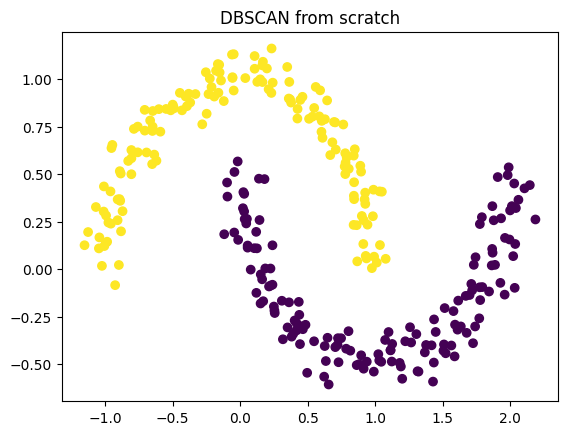

In [10]:
labels = dbscan_from_scratch(X, eps=0.2, min_samples=5)
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.title("DBSCAN from scratch")
plt.show()

In [11]:
print(labels.shape)
print(np.unique(labels))

(300,)
[0 1]


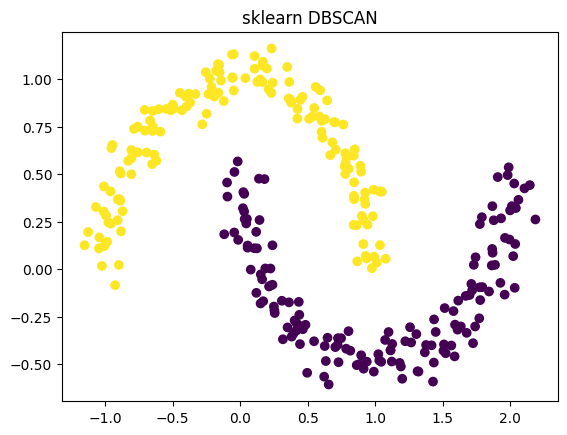

[0 1]


In [13]:
## Scratch implementation check with sklearn
from sklearn.cluster import DBSCAN


sk_dbscan = DBSCAN(eps=0.2, min_samples=5)
sk_labels = sk_dbscan.fit_predict(X)


plt.scatter(X[:,0], X[:,1], c=sk_labels, cmap='viridis')
plt.title("sklearn DBSCAN")
plt.show()

print(np.unique(sk_labels))

##	Hierarchical clustering: dendrogram
- cut at different heights, compare to K-Means

1. Hierarchical clustering builds the whole tree of nested clusters and afterwards it is decided how many clusters are needed by "CUTTING" the tree at a chosen height

## Hierarchical Clustering (Agglomerative)

**Idea:** Build a full tree of nested clusters bottom-up, then decide cluster count *after* seeing the tree no need to fix k upfront.

**Algorithm:**
1. Start: every point is its own cluster
2. Repeatedly merge the two closest clusters
3. Continue until everything is one cluster
4. Visualize as a dendrogram; "cut" at a chosen height to get k clusters

**Linkage criteria (how "distance between clusters" is defined):**
- Single: closest pair of points → prone to chaining (long snake-like clusters)
- Complete: farthest pair of points → avoids chaining, can break up clusters
- Average: mean of all pairwise distances → middle ground
- Ward: merge causing smallest increase in variance → compact, spherical-ish (most K-Means-like), most common default

**Reading a dendrogram:** height of a merge = dissimilarity at which two clusters joined. A horizontal cut line crosses N vertical lines = N clusters at that cut.

**fcluster cutting:**
- `criterion='maxclust', t=3` → fix number of clusters
- `criterion='distance', t=value` → fix merge-height threshold, cluster count falls out of that

**Best when:** unknown k, want to explore multiple granularities, interpretability matters (dendrogram tells a story)
**Struggles when:** large datasets (O(n²)+, slow and unreadable), can't undo a bad merge once made

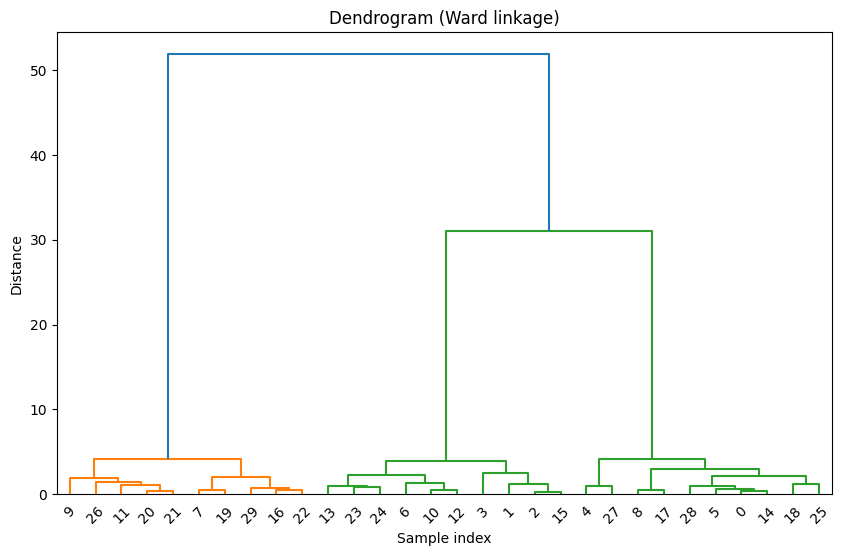

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs

X_small, _ = make_blobs(n_samples=30, centers=3, random_state=42)



# compute the linkage matrix
Z = linkage(X_small, method='ward')


plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrogram (Ward linkage)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

[3 2 2 2 3 3 2 1 3 1 2 1 2 2 3 2 1 3 3 1 1 1 1 2 2 3 1 3 3 1]


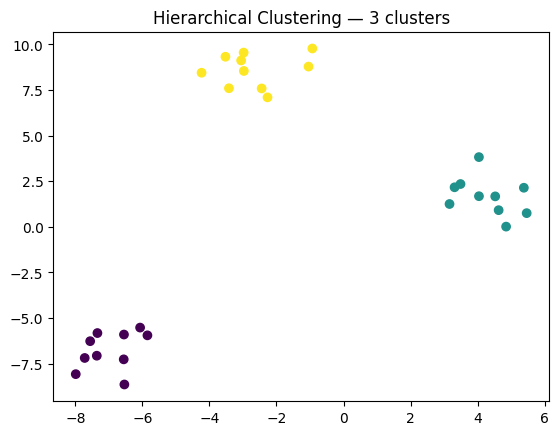

In [15]:
from scipy.cluster.hierarchy import fcluster

# cut the tree to get exactly 3 clusters
labels = fcluster(Z, t=3, criterion='maxclust')
print(labels)

plt.scatter(X_small[:,0], X_small[:,1], c=labels, cmap='viridis')
plt.title("Hierarchical Clustering — 3 clusters")
plt.show()

## Clustering Decision Guide

| Method | Best when... | Struggles when... |
|---|---|---|
| **K-Means** | Clusters are roughly spherical/convex, similar size, and you can estimate k via elbow/silhouette | Non-spherical shapes (crescents, rings), clusters of very different sizes/densities, outliers (forces every point into a cluster) |
| **DBSCAN** | Clusters are irregular/non-spherical shapes, dataset has noise/outliers you want to detect, unknown number of clusters | Clusters with varying density — since eps/min_samples are global, a good eps for a dense cluster may fail on a sparser one nearby. Also struggles in high dimensions (distance becomes less meaningful) |
| **Hierarchical** | You don't know k upfront and want to explore structure at multiple granularities; small-to-medium datasets; interpretability matters (dendrogram tells a story) | Computationally expensive — O(n²) or worse, doesn't scale well to large datasets (thousands+ points get visually unreadable and slow to compute); once merged, can't undo a bad merge |